In [1]:
# Implement and compare RNN, LSTM, and GRU models for sequence classification, and
# analyze their performance using appropriate evaluation metrics.

In [2]:
!pip -q install scikit-learn

In [3]:
# import libraries
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [4]:
# Load the IMDB movie review dataset
max_features = 10000
maxlen = 200

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=max_features
)

# Make all sequences the same length
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (25000, 200)
Testing data shape: (25000, 200)
Training labels shape: (25000,)
Testing labels shape: (25000,)


In [5]:
# Check the number of positive and negative reviews
print("Negative reviews:", np.sum(y_train == 0))
print("Positive reviews:", np.sum(y_train == 1))

Negative reviews: 12500
Positive reviews: 12500


In [6]:
# Build RNN, LSTM, or GRU model
def build_model(kind):
    model = Sequential([
        Embedding(max_features, 128)
    ])

    if kind == "RNN":
        model.add(SimpleRNN(64))
    elif kind == "LSTM":
        model.add(LSTM(64))
    elif kind == "GRU":
        model.add(GRU(64))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [7]:
# Train the Simple RNN model
rnn_model = build_model("RNN")

rnn_history = rnn_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6772 - loss: 0.5774 - val_accuracy: 0.8184 - val_loss: 0.4223
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8578 - loss: 0.3410 - val_accuracy: 0.8380 - val_loss: 0.4023
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9360 - loss: 0.1743 - val_accuracy: 0.7876 - val_loss: 0.5046


In [8]:
# Train the LSTM model
lstm_model = build_model("LSTM")

lstm_history = lstm_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7736 - loss: 0.4552 - val_accuracy: 0.8686 - val_loss: 0.3320
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9030 - loss: 0.2460 - val_accuracy: 0.8598 - val_loss: 0.3211
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9384 - loss: 0.1702 - val_accuracy: 0.8658 - val_loss: 0.3269


In [9]:
# Train the GRU model
gru_model = build_model("GRU")

gru_history = gru_model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7474 - loss: 0.4895 - val_accuracy: 0.8290 - val_loss: 0.3840
Epoch 2/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.8942 - loss: 0.2653 - val_accuracy: 0.8636 - val_loss: 0.3282
Epoch 3/3
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9263 - loss: 0.1937 - val_accuracy: 0.8448 - val_loss: 0.3603


In [10]:
# Evaluate a model using classification metrics
def evaluate_model(model, name):
    probabilities = model.predict(x_test, verbose=0)
    predictions = (probabilities > 0.5).astype(int).ravel()

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    cm = confusion_matrix(y_test, predictions)

    print(f"\n{name} Classification Report")
    print("-" * 40)
    print(classification_report(
        y_test,
        predictions,
        target_names=["Negative", "Positive"]
    ))

    print("Confusion Matrix:")
    print(cm)

    return [name, accuracy, precision, recall, f1], cm

In [11]:
# Evaluate all three models
rnn_result, rnn_cm = evaluate_model(rnn_model, "RNN")
lstm_result, lstm_cm = evaluate_model(lstm_model, "LSTM")
gru_result, gru_cm = evaluate_model(gru_model, "GRU")


RNN Classification Report
----------------------------------------
              precision    recall  f1-score   support

    Negative       0.83      0.73      0.78     12500
    Positive       0.76      0.85      0.80     12500

    accuracy                           0.79     25000
   macro avg       0.80      0.79      0.79     25000
weighted avg       0.80      0.79      0.79     25000

Confusion Matrix:
[[ 9162  3338]
 [ 1884 10616]]

LSTM Classification Report
----------------------------------------
              precision    recall  f1-score   support

    Negative       0.87      0.85      0.86     12500
    Positive       0.85      0.88      0.87     12500

    accuracy                           0.86     25000
   macro avg       0.86      0.86      0.86     25000
weighted avg       0.86      0.86      0.86     25000

Confusion Matrix:
[[10618  1882]
 [ 1518 10982]]

GRU Classification Report
----------------------------------------
              precision    recall  f1-score

In [12]:
# Create a comparison table
results = [
    rnn_result,
    lstm_result,
    gru_result
]

df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"]
)

print(df.round(4))

  Model  Accuracy  Precision  Recall  F1-Score
0   RNN    0.7911     0.7608  0.8493    0.8026
1  LSTM    0.8640     0.8537  0.8786    0.8660
2   GRU    0.8531     0.8156  0.9125    0.8613


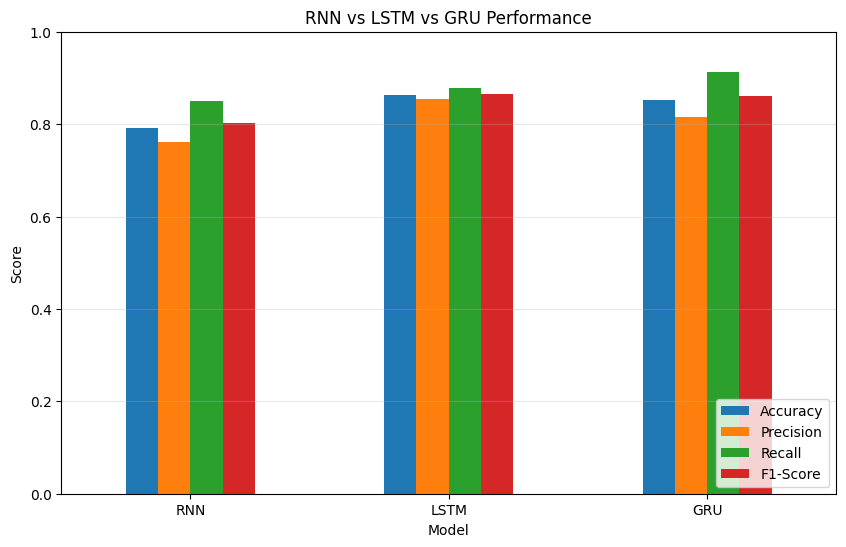

In [13]:
# Plot performance comparison
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

df_plot = df.set_index("Model")[metrics]

df_plot.plot(kind="bar", figsize=(10, 6))

plt.title("RNN vs LSTM vs GRU Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)

plt.show()

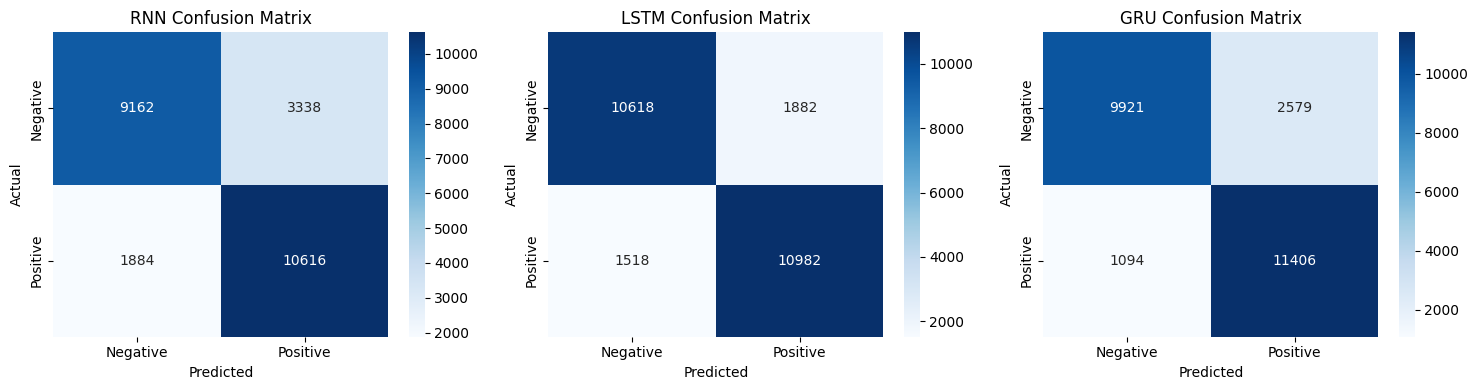

In [15]:
# Display confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

confusion_matrices = [
    (rnn_cm, "RNN"),
    (lstm_cm, "LSTM"),
    (gru_cm, "GRU")
]

for ax, (cm, name) in zip(axes, confusion_matrices):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        ax=ax
    )

    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

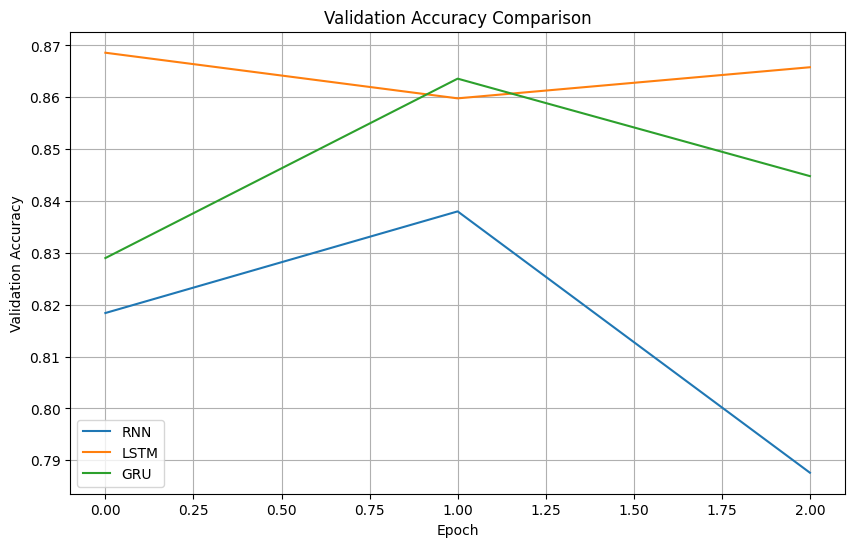

In [16]:
# Compare training and validation accuracy
plt.figure(figsize=(10, 6))

plt.plot(rnn_history.history["val_accuracy"], label="RNN")
plt.plot(lstm_history.history["val_accuracy"], label="LSTM")
plt.plot(gru_history.history["val_accuracy"], label="GRU")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

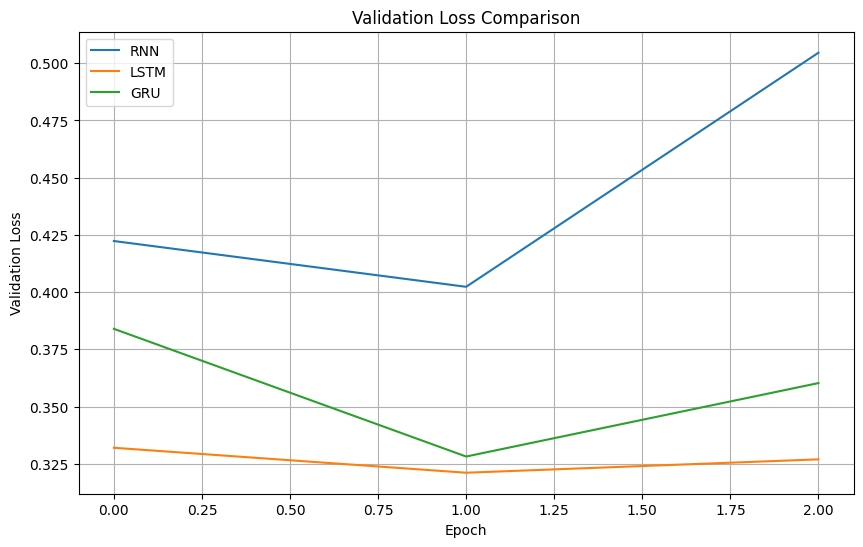

In [17]:
# Compare validation loss
plt.figure(figsize=(10, 6))

plt.plot(rnn_history.history["val_loss"], label="RNN")
plt.plot(lstm_history.history["val_loss"], label="LSTM")
plt.plot(gru_history.history["val_loss"], label="GRU")

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

In [18]:
# Display the highest observed value for each metric
for metric in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    best_value = df[metric].max()
    models = df.loc[df[metric] == best_value, "Model"].tolist()

    print(f"{metric}: {best_value:.4f} ({', '.join(models)})")

Accuracy: 0.8640 (LSTM)
Precision: 0.8537 (LSTM)
Recall: 0.9125 (GRU)
F1-Score: 0.8660 (LSTM)
